In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import subprocess
import re
import os

# まずは，crime のデータに分類辞書を結合する

crime_dict = pd.read_csv(r"crime_dictionary.csv")

# まずは，各年のcrime.csvを縦結合し，5年分のデータを作る
dfs = {}

for year in range(2020, 2024+1):
    dfs[year] = pd.read_csv(rf"Crimes{year}.csv") 
    # dfs.append(df)

crime = pd.concat(dfs.values(), ignore_index=True)

col = crime.pop("year")
crime.insert(1, "year", col)


# 次に，crime のデータに分類辞書を結合する
crime_dict = pd.read_csv(r"crime_dictionary.csv")

crime_merge = pd.merge(crime, crime_dict, on = "primary_type", how = "left")
col = crime_merge.pop("crime_group1_prime")
crime_merge.insert(2, "crime_group1_prime", col)
crime_merge.rename(columns = {"crime_group1_prime" : "crimetype"}, inplace = True)


# 最後に，年別，コミュニティエリア別の集計表を作る
crime_summary = (
    crime_merge
    .groupby(["year", "community_area", "crimetype"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)


### 次に，ACSのデータをcommunity_areaごとに集計

# データセットの読み込み，リポジトリよりファイルを抽出
# Git管理されている _2020-2024.csv ファイルを取得
files = subprocess.check_output(
    ["git", "ls-files", "*_2020-2024.csv"],
    text=True
).splitlines()

# ACS_ と _2020-2024.csv の間を抽出
acs_list = [
    re.search(r"ACS(.*?)_2020-2024\.csv", f).group(1)
    for f in files
    if re.search(r"ACS(.*?)_2020-2024\.csv", f)
]

acs_summary = None

for dataset in acs_list:

    # 読み込み
    df1 = pd.read_csv(f"ACS{dataset}_2020-2024.csv")
    
    # 後ろ10列を除外
    sum_cols = df1.columns[:-10]

    # グループキーを除外
    sum_cols = [
        col for col in sum_cols
        if col not in ["year", "community_area"]
    ]

    # year × community_areaで集計
    result = (
        df1.groupby(
            ["year", "community_area"],
            as_index=False
        )[sum_cols]
        .sum()
    )


    # 横結合
    if acs_summary is None:
        acs_summary = result
    else:
        acs_summary = pd.merge(
            acs_summary,
            result,
            on=["year", "community_area"],
            how="outer"
        )


## 最後に，headerにcrime_summaryとacs_summaryを横結合
header = pd.read_csv("header.csv")

chicago = pd.merge(header, crime_summary, on = ["year", "community_area"],
                   how = "left")

chicago = pd.merge(chicago, acs_summary, 
                   on = ["year", "community_area"],
                   how = "left")

col = list(chicago.columns) 
exclude = ['community', 'commarea_km2']
int_col = [c for c in col if c not in exclude]
chicago[int_col] = chicago[int_col].astype(int)
chicago["community_area"] = chicago["community_area"].astype("category")


# chicago.to_csv("chicago.csv", index = False)




整数で入力してください
整数で入力してください
1〜77の範囲で入力してください

選択された変数:
['comm_pop', 'other1', 'allblackpop', 'public_order1', 'malepop']


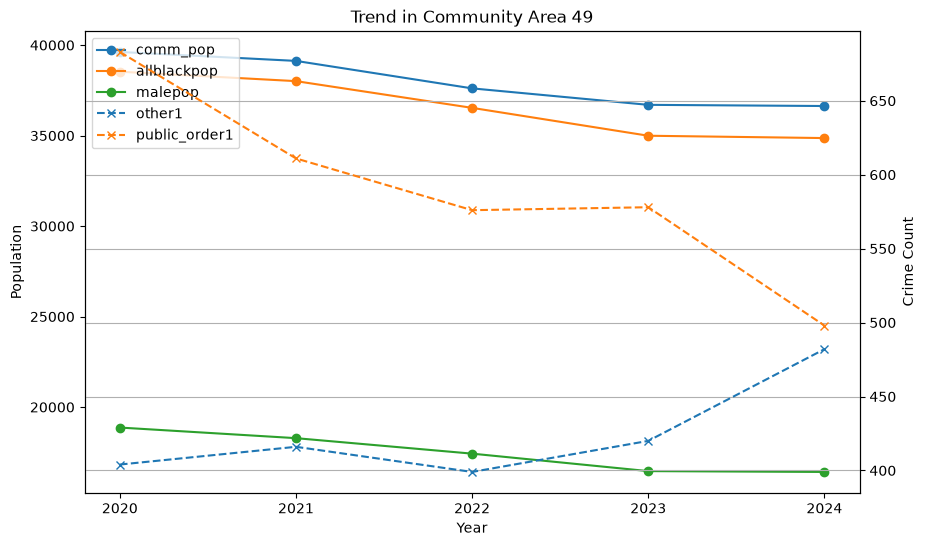

In [ ]:
# ==============================
# 変数リスト
# ==============================

# 人口系変数
population_vars = [
    "comm_pop",
    "malepop",
    "male15_19pop",
    "male15_24pop",
    "male15_29pop",
    "allwhitepop",
    "allblackpop"
]


# 犯罪系変数
crime_vars = [
    "other1",
    "property1",
    "public_order1",
    "violent1"
]


# ==============================
# 利用可能変数作成
# ==============================

available_vars = [
    col for col in chicago.columns
    if col not in [
        "year",
        "community_area",
        "community",
        "commarea_km2"
    ]
]


# 番号付き一覧
variable_text = "\n".join(
    [
        f"{i}: {var}"
        for i, var in enumerate(
            available_vars,
            start=1
        )
    ]
)


# ==============================
# Community Area入力
# ==============================

while True:

    try:

        area = int(
            input(
                "Community Areaを入力してください（1〜77）: "
            )
        )

        if 1 <= area <= 77:
            break

        else:
            print("1〜77の範囲で入力してください")

    except ValueError:

        print("整数で入力してください")


# ==============================
# 変数選択
# ==============================

# 番号付き変数一覧を作成
variable_text = "\n".join(
    [
        f"{i}: {var}"
        for i, var in enumerate(
            available_vars,
            start=1
        )
    ]
)


while True:

    # input画面内に一覧を表示
    selected_numbers = input(
        "\n利用可能な変数:\n"
        "--------------------\n"
        f"{variable_text}\n"
        "--------------------\n\n"
        "表示する変数番号を入力してください"
        "（カンマ区切り、最大5個）: "
    )


    # カンマ分割
    selected_numbers = [
        x.strip()
        for x in selected_numbers.split(",")
        if x.strip()
    ]


    try:

        selected_numbers = [
            int(x)
            for x in selected_numbers
        ]

    except ValueError:

        print(
            "番号で入力してください"
        )
        continue


    # 個数チェック
    if len(selected_numbers) > 5:

        print(
            "最大5個までです"
        )
        continue


    # 範囲チェック
    if not all(
        1 <= x <= len(available_vars)
        for x in selected_numbers
    ):

        print(
            "存在する番号を入力してください"
        )
        continue


    break



# 番号 → 変数名へ変換
variables = [
    available_vars[i-1]
    for i in selected_numbers
]


print("\n選択された変数:")
print(variables)

# ==============================
# データ抽出
# ==============================

# # 型を統一
# chicago["community_area"] = (
#     chicago["community_area"]
#     .astype(int)
# )


data = (
    chicago[
        chicago["community_area"] == area
    ]
    .sort_values("year")
)



if data.empty:

    print(
        "該当するCommunity Areaがありません"
    )


else:


    # ==============================
    # グラフ作成
    # ==============================

    fig, ax1 = plt.subplots(
        figsize=(10,6)
    )


    # 選択変数分類

    pop_selected = [
        v for v in variables
        if v in population_vars
    ]


    crime_selected = [
        v for v in variables
        if v in crime_vars
    ]


    # ==============================
    # 人口グラフ
    # ==============================

    if pop_selected:

        for var in pop_selected:

            ax1.plot(
                data["year"],
                data[var],
                marker="o",
                label=var
            )


        ax1.set_ylabel(
            "Population"
        )



    # ==============================
    # 犯罪グラフ
    # ==============================

    ax2 = None


    if crime_selected:

        ax2 = ax1.twinx()


        for var in crime_selected:

            ax2.plot(
                data["year"],
                data[var],
                marker="x",
                linestyle="--",
                label=var
            )


        ax2.set_ylabel(
            "Crime Count"
        )



    # ==============================
    # 凡例統合
    # ==============================

    lines1, labels1 = (
        ax1.get_legend_handles_labels()
    )


    if ax2:

        lines2, labels2 = (
            ax2.get_legend_handles_labels()
        )


        ax1.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc="upper left"
        )


    else:

        ax1.legend(
            loc="upper left"
        )



    # X軸
    ax1.set_xticks(
        data["year"]
    )


    ax1.set_xlabel(
        "Year"
    )


    plt.title(
        f"Trend in Community Area {area}"
    )


    plt.grid(
        True
    )


    plt.show()